In [82]:
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

In [83]:
train_path = "data/train"
validation_path = "data/validation"

In [84]:
print(os.listdir(train_path))
print(os.listdir(validation_path))

['horse-or-human']
['validation-horse-or-human']


In [85]:
train_horse_path = train_path + "/horse-or-human/horses"
train_human_path = train_path + "/horse-or-human/humans"

validation_horse_path = validation_path + "/validation-horse-or-human/horses"
validation_human_path = validation_path + "/validation-horse-or-human/humans"

# horse_file = os.listdir(horse_path)
#
# print(horse_file[:5])
# print(len(horse_file))


In [86]:
def load_class_data(directory, label):
    images = []
    labels = []
    filenames = sorted(os.listdir(directory))
    for filename in filenames:
        image_path = os.path.join(directory, filename)
        with Image.open(image_path) as img:
            img = img.convert("RGB").resize((128,128))
            image_array = np.array(img)

        images.append(image_array)
        labels.append(label)

    # print(type(images))
    # print(type(images[0]))
    # print(type(labels))
    # print(type(labels[0]))

    return np.array(images), np.array(labels)

In [87]:
train_horse_images, train_horse_labels = load_class_data(train_horse_path, 0)
train_human_images, train_human_labels = load_class_data(train_human_path, 1)

validation_horse_images, validation_horse_labels = load_class_data(validation_horse_path, 0)
validation_human_images, validation_human_labels = load_class_data(validation_human_path, 1)

# print(type(train_horse_images))
# print(type(train_horse_images[0]))
# print(type(train_horse_labels))
# print(type(train_horse_labels[0]))


```The next is to join the both classes  into one training-image collection```

In [88]:
def load_total_data(human_images, human_labels, horse_images, horse_labels):
    total_images =  np.concatenate((human_images,horse_images))
    total_labels = np.concatenate((human_labels,horse_labels))

    return total_images, total_labels


In [89]:
train_images, train_labels = load_total_data(
    train_horse_images,
    train_horse_labels,
    train_human_images,
    train_human_labels
)

validation_images, validation_labels = load_total_data(
    validation_horse_images,
    validation_horse_labels,
    validation_human_images,
    validation_human_labels
)

In [90]:
print(train_images.shape)
print(train_labels.shape)
print(validation_images.shape)
print(validation_labels.shape)

(1027, 128, 128, 3)
(1027,)
(256, 128, 128, 3)
(256,)


In [91]:
# print(train_images[:2])
# print(train_labels[:2])

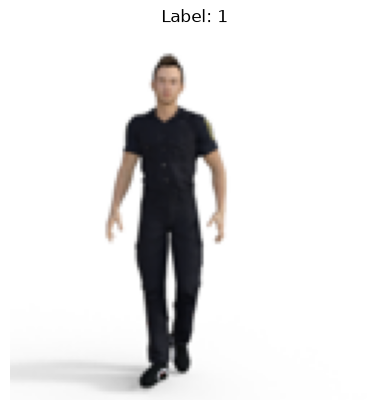

In [97]:
index = 128
plt.imshow(validation_images[index]) # interpret as image
plt.title(f"Label: {validation_labels[index]}")
plt.axis("off")
plt.show()

In [93]:
X_train = train_images
y_train = train_labels
X_validation = validation_images
y_validation = validation_labels
print(X_train.shape)

(1027, 128, 128, 3)


## Data preprocessing

We flatten and normalize the images before training. Normalization places the pixel values on a smaller scale, which can make gradient descent more stable and help it converge faster.

The training examples are shuffled at the beginning of each epoch before they are divided into mini-batches.

In [94]:
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
y_train = y_train.reshape(1,-1)

X_validation_flattened = X_validation.reshape(X_validation.shape[0], -1)
y_validation = y_validation.reshape(1,-1)

X_train_flattened = X_train_flattened.T
X_validation_flattened = X_validation_flattened.T


In [95]:

mean = np.mean(X_train_flattened, axis=1, keepdims=True)
std = np.std(X_train_flattened, axis=1, keepdims=True)
safe_std = np.where(std  == 0, 1,std )
X_train_normalized = (X_train_flattened - mean) / safe_std
X_validation_normalized = (X_validation_flattened - mean) / safe_std

# print(X_train_normalized.shape)
# print(X_validation_normalized.shape)
# print(y_train.shape)


(49152, 1027)
(49152, 256)
(1, 1027)


In [96]:
rng = np.random.default_rng(42) # makes the shuffling reproducible
permutation = rng.permutation(X_train_normalized.shape[1])

X_train_shuffled= X_train_normalized[:,permutation]
y_train_shuffled = y_train[:,permutation]


#
# print(X_train_shuffled[:1])


[[ 1.06601956  1.05046442 -1.29836221 ...  0.77047184  1.20601585
   0.14826611]]
